In [43]:
library(shazam)

db <- read.table(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/data/output/repertorio_D_insilico_102400_seqs_db-pass.tsv",
  header = TRUE,
  sep = "\t"
)

dist <- distToNearest(
  db,
  sequenceColumn = "junction",
  vCallColumn = "v_call",
  jCallColumn = "j_call",
  model = "ham",
  normalize = "len"
)$dist_nearest

dist <- dist[!is.na(dist)]

out <- findThreshold(dist, method = "density")

out@threshold

Running in non-single-cell mode.

Warning message in max(el[, 3]):
"no non-missing arguments to max; returning -Inf"


[1] NA

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0175  0.1778  0.2381  0.2396  0.2963  0.5455 

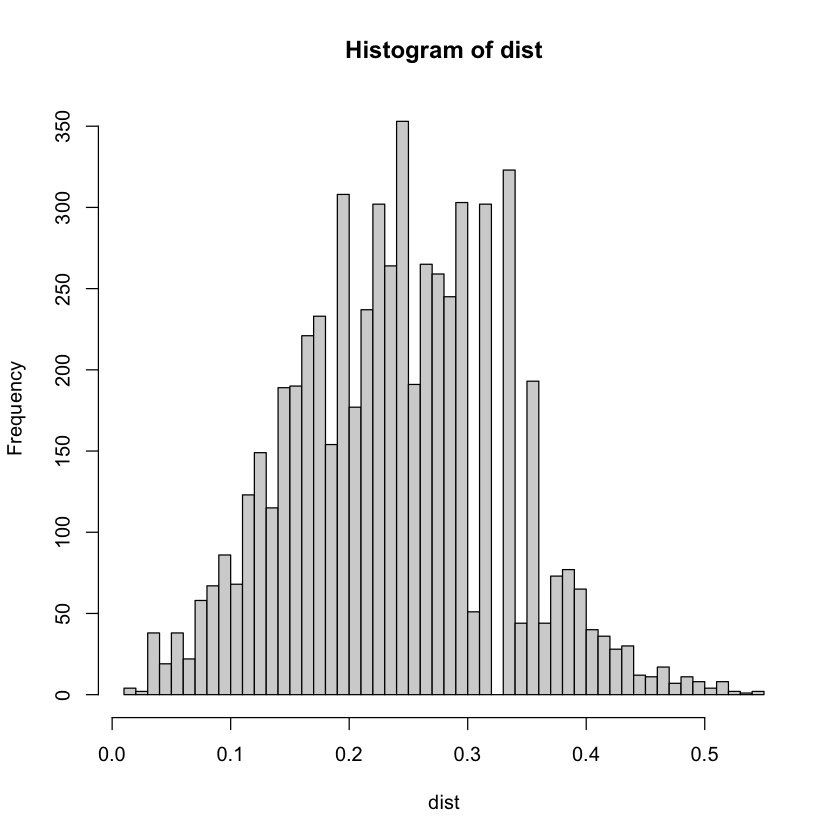

In [56]:
hist(dist, breaks = 50)
summary(dist)

Warning message:
"Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`)."


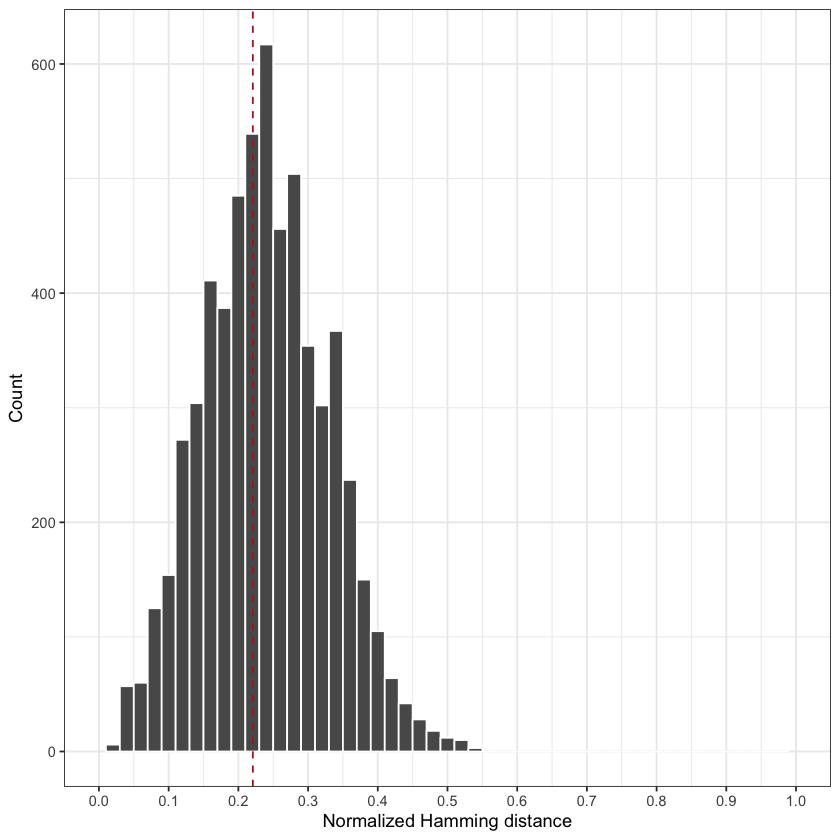

In [57]:
library(ggplot2)

threshold <- out@threshold

p1 <- ggplot(data.frame(dist = dist), aes(x = dist)) +
  geom_histogram(
    color = "white",
    binwidth = 0.02
  ) +
  geom_vline(
    xintercept = threshold,
    color = "firebrick",
    linetype = 2
  ) +
  labs(
    x = "Normalized Hamming distance",
    y = "Count"
  ) +
  scale_x_continuous(
    breaks = seq(0, 1, 0.1),
    limits = c(0, 1)
  ) +
  theme_bw()

p1